<a href="https://colab.research.google.com/github/RaccoonNextDoor/Project-Repository/blob/main/notebooks/Project-Week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [145]:
from google.colab import userdata
import subprocess

token = userdata.get("GHpat")

if not token:
    raise ValueError("The Colab secret named GHpat was not found.")

result = subprocess.run(
    [
        "gh", "auth", "login",
        "--hostname", "github.com",
        "--git-protocol", "https",
        "--with-token"
    ],
    input=token + "\n",
    text=True,
    capture_output=True
)

print("Return code:", result.returncode)
print("GitHub CLI message:")
print(result.stderr)

Return code: 0
GitHub CLI message:



In [146]:
!gh auth setup-git
!gh auth status

github.com
  ✓ Logged in to github.com account RaccoonNextDoor (/root/.config/gh/hosts.yml)
  - Active account: true
  - Git operations protocol: https
  - Token: github_pat_11BR62L3Y0U4aakgiPdfqN_***********************************************************


In [147]:
%cd /content

!git clone https://github.com/RaccoonNextDoor/Project-Repository.git

%cd /content/Project-Repository

/content
fatal: destination path 'Project-Repository' already exists and is not an empty directory.
/content/Project-Repository


In [148]:
%cd /content/Project-Repository

!mkdir -p src data examples tests notebooks

/content/Project-Repository


In [149]:
!touch src/.gitkeep
!touch data/.gitkeep
!touch examples/.gitkeep
!touch tests/.gitkeep
!touch notebooks/.gitkeep

In [150]:
%%writefile .gitignore
__pycache__/
*.pyc
.ipynb_checkpoints/
.env
.DS_Store

Overwriting .gitignore


In [151]:
%%writefile README.md
# Project Repository

This repository contains the engineering software project developed for this unit.

## Project structure

- `src/` — source code
- `data/` — project data
- `examples/` — example programs
- `tests/` — software tests
- `notebooks/` — Google Colab and Jupyter notebooks

## Development tools

- Python
- Google Colab
- Git
- GitHub

## Licence

No licence has currently been applied to this repository.

Overwriting README.md


In [152]:
!find . -maxdepth 2 -type f

./data/.gitkeep
./.git/HEAD
./.git/config
./.git/index
./.git/ORIG_HEAD
./.git/FETCH_HEAD
./.git/packed-refs
./.git/description
./.git/COMMIT_EDITMSG
./reports/pdb_session.txt
./reports/pytest_report.html
./.pytest_cache/README.md
./.pytest_cache/.gitignore
./.pytest_cache/CACHEDIR.TAG
./tests/.gitkeep
./tests/test_matrix_operations.py
./README.md
./src/__init__.py
./src/matrix_operations.py
./src/.gitkeep
./notebooks/.gitkeep
./notebooks/Project-Week1.ipynb
./.gitignore
./examples/.gitkeep
./docs/matmul_flowchart.mmd
./docs/pdb_debugging_report.md
./docs/matmul_flowchart.md


In [153]:
%cd /content/Project-Repository

!git config user.name "Zheng Zhou"
!git config user.email "zzho0105@student.monash.edu"

/content/Project-Repository


In [154]:
!git add .
!git commit -m "Set up initial project structure"
!git push origin main

[main d9225a2] Set up initial project structure
 1 file changed, 12 deletions(-)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (2/2), done.
Writing objects: 100% (3/3), 304 bytes | 304.00 KiB/s, done.
Total 3 (delta 2), reused 1 (delta 1), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/RaccoonNextDoor/Project-Repository.git
   d6443fb..d9225a2  main -> main


In [155]:
%cd /content/Project-Repository

!git pull origin main
!find . -maxdepth 3 -type f -not -path "./.git/*" | sort

/content/Project-Repository
From https://github.com/RaccoonNextDoor/Project-Repository
 * branch            main       -> FETCH_HEAD
Already up to date.
./data/.gitkeep
./docs/api/index.html
./docs/api/search.js
./docs/matmul_flowchart.md
./docs/matmul_flowchart.mmd
./docs/pdb_debugging_report.md
./examples/.gitkeep
./.gitignore
./notebooks/.gitkeep
./notebooks/Project-Week1.ipynb
./.pytest_cache/CACHEDIR.TAG
./.pytest_cache/.gitignore
./.pytest_cache/README.md
./README.md
./reports/pdb_session.txt
./reports/pytest_report.html
./src/.gitkeep
./src/__init__.py
./src/matrix_operations.py
./src/__pycache__/__init__.cpython-312.pyc
./src/__pycache__/matrix_operations.cpython-312.pyc
./tests/.gitkeep
./tests/__pycache__/test_matrix_operations.cpython-312-pytest-8.4.2.pyc
./tests/test_matrix_operations.py


# Task 2 — AI Usage Statement

This section adds an AI usage statement to the project README file.

In [156]:
%cd /content/Project-Repository

!git pull origin main

!git config user.name "Zheng Zhou"
!git config user.email "zzho0105@student.monash.edu"

import subprocess


def commit_and_push(message: str) -> None:
    """Stage all project changes, create a commit, and push it to GitHub."""
    subprocess.run(["git", "add", "."], check=True)

    # Return code 0 means that there are no staged differences.
    staged_changes = subprocess.run(
        ["git", "diff", "--cached", "--quiet"]
    )

    if staged_changes.returncode == 0:
        print("No new changes to commit.")
        return

    subprocess.run(
        ["git", "commit", "-m", message],
        check=True,
    )

    subprocess.run(
        ["git", "push", "origin", "main"],
        check=True,
    )

    print("Changes committed and pushed successfully.")

/content/Project-Repository
From https://github.com/RaccoonNextDoor/Project-Repository
 * branch            main       -> FETCH_HEAD
Already up to date.


In [157]:
from pathlib import Path

readme_path = Path("README.md")
readme_text = readme_path.read_text(encoding="utf-8")

ai_statement = """
## AI Usage Statement

Generative AI tools, including ChatGPT, were used to assist with explaining
the Git and GitHub workflow, drafting Python comments and docstrings,
developing the Mermaid flowchart, proposing software test cases, and
providing guidance for the debugging activity.

All AI-generated material was reviewed, executed, tested, and modified by
the project author before being included in the repository. The project
author remains responsible for the correctness, originality, and quality
of the final code and documentation.
"""

if "## AI Usage Statement" not in readme_text:
    updated_readme = readme_text.rstrip() + "\n\n" + ai_statement.strip() + "\n"
    readme_path.write_text(updated_readme, encoding="utf-8")
    print("AI usage statement added to README.md.")
else:
    print("README.md already contains an AI usage statement.")

AI usage statement added to README.md.


In [158]:
print(Path("README.md").read_text(encoding="utf-8"))

# Project Repository

This repository contains the engineering software project developed for this unit.

## Project structure

- `src/` — source code
- `data/` — project data
- `examples/` — example programs
- `tests/` — software tests
- `notebooks/` — Google Colab and Jupyter notebooks

## Development tools

- Python
- Google Colab
- Git
- GitHub

## Licence

No licence has currently been applied to this repository.

## AI Usage Statement

Generative AI tools, including ChatGPT, were used to assist with explaining
the Git and GitHub workflow, drafting Python comments and docstrings,
developing the Mermaid flowchart, proposing software test cases, and
providing guidance for the debugging activity.

All AI-generated material was reviewed, executed, tested, and modified by
the project author before being included in the repository. The project
author remains responsible for the correctness, originality, and quality
of the final code and documentation.



In [159]:
commit_and_push("Add AI usage statement to README")

Changes committed and pushed successfully.


# Task 3 — Inline Comments, Docstrings and Documentation

A documented implementation of matrix multiplication is created in the
`src` folder. The source code includes type annotations, docstrings,
input validation, and meaningful inline comments.

The documentation webpage is generated automatically from the Python
docstrings using `pdoc`.

In [160]:
%%writefile src/matrix_operations.py
"""Matrix operations used in the project exercises."""

Number = int | float
Matrix = list[list[Number]]


def _matrix_shape(matrix: Matrix, name: str) -> tuple[int, int]:
    """Validate a matrix and return its number of rows and columns.

    Args:
        matrix: Matrix represented as a list of non-empty rows.
        name: Matrix name used in error messages.

    Returns:
        A tuple containing ``(number_of_rows, number_of_columns)``.

    Raises:
        ValueError: If the matrix is empty, contains an empty row,
            or has rows of unequal length.
        TypeError: If a matrix entry is not an integer or float.
    """
    if not isinstance(matrix, list) or not matrix:
        raise ValueError(f"{name} must be a non-empty list of rows.")

    if any(not isinstance(row, list) or not row for row in matrix):
        raise ValueError(f"{name} must contain non-empty list rows.")

    column_count = len(matrix[0])

    # Every row must have the same number of entries for the matrix
    # to be rectangular.
    if any(len(row) != column_count for row in matrix):
        raise ValueError(f"{name} must be rectangular.")

    # This implementation only accepts numeric matrix entries.
    if any(
        not isinstance(value, (int, float))
        for row in matrix
        for value in row
    ):
        raise TypeError(f"{name} must contain only numeric values.")

    return len(matrix), column_count


def matmul(a: Matrix, b: Matrix) -> Matrix:
    """Multiply two matrices using the standard triple-loop algorithm.

    The number of columns in ``a`` must equal the number of rows in ``b``.

    Args:
        a: Left matrix with dimensions ``m × n``.
        b: Right matrix with dimensions ``n × p``.

    Returns:
        The product matrix with dimensions ``m × p``.

    Raises:
        ValueError: If a matrix is invalid or the dimensions are
            incompatible.
        TypeError: If either matrix contains a non-numeric value.

    Example:
        >>> matmul([[1, 2]], [[3], [4]])
        [[11]]
    """
    m, n = _matrix_shape(a, "Matrix A")
    n_b, p = _matrix_shape(b, "Matrix B")

    if n != n_b:
        raise ValueError(
            "Matrix A column count must equal Matrix B row count."
        )

    # Start with an m × p result matrix filled with zeros.
    result: Matrix = [
        [0 for _ in range(p)]
        for _ in range(m)
    ]

    # Each result entry is the dot product of one row of A
    # and one column of B.
    for i in range(m):
        for j in range(p):
            total: Number = 0

            for k in range(n):
                total += a[i][k] * b[k][j]

            result[i][j] = total

    return result

Overwriting src/matrix_operations.py


In [161]:
%%writefile src/__init__.py
"""Source package for the engineering software project."""

from .matrix_operations import matmul

__all__ = ["matmul"]

Overwriting src/__init__.py


In [162]:
from src.matrix_operations import matmul

matrix_a = [
    [1, 2],
    [3, 4],
]

matrix_b = [
    [5, 6],
    [7, 8],
]

result = matmul(matrix_a, matrix_b)

print("Matrix A:")
print(matrix_a)

print("\nMatrix B:")
print(matrix_b)

print("\nA × B:")
print(result)

assert result == [[19, 22], [43, 50]]
print("\nDemonstration passed.")

Matrix A:
[[1, 2], [3, 4]]

Matrix B:
[[5, 6], [7, 8]]

A × B:
[[19, 22], [43, 50]]

Demonstration passed.


In [163]:
!pip install -q pdoc

In [164]:
%cd /content/Project-Repository

!rm -rf docs/api
!mkdir -p docs/api

!pdoc ./src/matrix_operations.py -o ./docs/api

print("Generated documentation files:")
!find docs/api -type f | sort

/content/Project-Repository
Generated documentation files:
docs/api/index.html
docs/api/search.js
docs/api/src/matrix_operations.html


In [165]:
from pathlib import Path
from IPython.display import HTML, display

html_files = sorted(Path("docs/api").rglob("*.html"))

if not html_files:
    raise FileNotFoundError("No pdoc HTML documentation was generated.")

for html_file in html_files:
    print(html_file)

documentation_file = next(
    (
        file
        for file in html_files
        if file.name == "matrix_operations.html"
    ),
    html_files[0],
)

print(f"\nDisplaying: {documentation_file}")
display(
    HTML(
        documentation_file.read_text(
            encoding="utf-8",
            errors="replace",
        )
    )
)

docs/api/index.html
docs/api/src/matrix_operations.html

Displaying: docs/api/src/matrix_operations.html


In [166]:
commit_and_push(
    "Add documented matrix multiplication algorithm and API webpage"
)

No new changes to commit.


# Task 4 — Mermaid Flowchart for Matrix Multiplication

The flowchart communicates the control flow of the matrix multiplication
algorithm.

Standard flowchart conventions are used:

- Rounded shapes represent start and end points.
- Parallelograms represent inputs and outputs.
- Rectangles represent processing operations.
- Diamonds represent decisions and loop conditions.

In [167]:
!pip install -q colab-print

In [168]:
from pathlib import Path
from colab_print import mermaid

flowchart = """
flowchart TD
    START([Start])
    INPUT[/Receive matrices A and B/]
    SHAPE[Determine m, n, n_b and p]
    DIMENSION{"Does n equal n_b?"}
    ERROR[/Raise ValueError/]
    INITIALISE[Create an m by p zero matrix C]

    SET_I[Set i = 0]
    CHECK_I{"Is i less than m?"}

    SET_J[Set j = 0]
    CHECK_J{"Is j less than p?"}

    SET_K[Set total = 0 and k = 0]
    CHECK_K{"Is k less than n?"}

    MULTIPLY["total = total + A[i][k] * B[k][j]"]
    INCREMENT_K[k = k + 1]

    STORE["C[i][j] = total"]
    INCREMENT_J[j = j + 1]
    INCREMENT_I[i = i + 1]

    OUTPUT[/Return matrix C/]
    END([End])

    START --> INPUT
    INPUT --> SHAPE
    SHAPE --> DIMENSION

    DIMENSION -- No --> ERROR
    ERROR --> END

    DIMENSION -- Yes --> INITIALISE
    INITIALISE --> SET_I
    SET_I --> CHECK_I

    CHECK_I -- No --> OUTPUT
    OUTPUT --> END

    CHECK_I -- Yes --> SET_J
    SET_J --> CHECK_J

    CHECK_J -- No --> INCREMENT_I
    INCREMENT_I --> CHECK_I

    CHECK_J -- Yes --> SET_K
    SET_K --> CHECK_K

    CHECK_K -- Yes --> MULTIPLY
    MULTIPLY --> INCREMENT_K
    INCREMENT_K --> CHECK_K

    CHECK_K -- No --> STORE
    STORE --> INCREMENT_J
    INCREMENT_J --> CHECK_J
"""

docs_directory = Path("docs")
docs_directory.mkdir(exist_ok=True)

# Store the original Mermaid script.
mermaid_source = docs_directory / "matmul_flowchart.mmd"
mermaid_source.write_text(
    flowchart.strip() + "\n",
    encoding="utf-8",
)

# Store a Markdown version that GitHub can render.
mermaid_markdown = docs_directory / "matmul_flowchart.md"
mermaid_markdown.write_text(
    "# Matrix Multiplication Flowchart\n\n"
    "```mermaid\n"
    + flowchart.strip()
    + "\n```\n",
    encoding="utf-8",
)

print(f"Saved Mermaid source to: {mermaid_source}")
print(f"Saved GitHub Markdown to: {mermaid_markdown}")

mermaid(flowchart, theme="default")

Saved Mermaid source to: docs/matmul_flowchart.mmd
Saved GitHub Markdown to: docs/matmul_flowchart.md


In [169]:
print(
    Path("docs/matmul_flowchart.mmd").read_text(
        encoding="utf-8"
    )
)

flowchart TD
    START([Start])
    INPUT[/Receive matrices A and B/]
    SHAPE[Determine m, n, n_b and p]
    DIMENSION{"Does n equal n_b?"}
    ERROR[/Raise ValueError/]
    INITIALISE[Create an m by p zero matrix C]

    SET_I[Set i = 0]
    CHECK_I{"Is i less than m?"}

    SET_J[Set j = 0]
    CHECK_J{"Is j less than p?"}

    SET_K[Set total = 0 and k = 0]
    CHECK_K{"Is k less than n?"}

    MULTIPLY["total = total + A[i][k] * B[k][j]"]
    INCREMENT_K[k = k + 1]

    STORE["C[i][j] = total"]
    INCREMENT_J[j = j + 1]
    INCREMENT_I[i = i + 1]

    OUTPUT[/Return matrix C/]
    END([End])

    START --> INPUT
    INPUT --> SHAPE
    SHAPE --> DIMENSION

    DIMENSION -- No --> ERROR
    ERROR --> END

    DIMENSION -- Yes --> INITIALISE
    INITIALISE --> SET_I
    SET_I --> CHECK_I

    CHECK_I -- No --> OUTPUT
    OUTPUT --> END

    CHECK_I -- Yes --> SET_J
    SET_J --> CHECK_J

    CHECK_J -- No --> INCREMENT_I
    INCREMENT_I --> CHECK_I

    CHECK_J -- Yes --> SET_K
  

In [170]:
commit_and_push("Add Mermaid matrix multiplication flowchart")

No new changes to commit.


# Task 5 — Test Functions and Pytest Report

Eight tests are created for the matrix multiplication algorithm:

## Positive cases

1. Square matrices
2. Rectangular matrices
3. Multiplication by an identity matrix
4. Matrices containing negative values

## Negative cases

5. Incompatible matrix dimensions
6. An empty matrix
7. A matrix with rows of unequal length
8. A matrix containing a non-numeric value

The negative cases verify that invalid input is handled by a clear exception
rather than producing an unexplained result.

In [171]:
%%writefile tests/test_matrix_operations.py
"""Pytest test cases for matrix multiplication."""

import pytest

from src.matrix_operations import matmul


# Positive case 1: ordinary square matrices.
def test_square_matrices():
    assert matmul(
        [[1, 2], [3, 4]],
        [[5, 6], [7, 8]],
    ) == [[19, 22], [43, 50]]


# Positive case 2: rectangular matrices.
def test_rectangular_matrices():
    assert matmul(
        [[1, 2, 3], [4, 5, 6]],
        [[7, 8], [9, 10], [11, 12]],
    ) == [[58, 64], [139, 154]]


# Positive case 3: multiplication by an identity matrix.
def test_identity_matrix():
    assert matmul(
        [[4, 7], [2, 6]],
        [[1, 0], [0, 1]],
    ) == [[4, 7], [2, 6]]


# Positive case 4: valid negative matrix values.
def test_negative_values():
    assert matmul(
        [[-1, 2]],
        [[3], [-4]],
    ) == [[-11]]


# Negative case 1: dimensions are incompatible.
def test_incompatible_dimensions():
    with pytest.raises(ValueError, match="column count"):
        matmul(
            [[1, 2, 3]],
            [[1, 2], [3, 4]],
        )


# Negative case 2: one matrix is empty.
def test_empty_matrix():
    with pytest.raises(ValueError, match="non-empty"):
        matmul([], [[1]])


# Negative case 3: rows have unequal lengths.
def test_ragged_matrix():
    with pytest.raises(ValueError, match="rectangular"):
        matmul(
            [[1, 2], [3]],
            [[1], [2]],
        )


# Negative case 4: a matrix contains non-numeric data.
def test_non_numeric_value():
    with pytest.raises(TypeError, match="numeric"):
        matmul(
            [[1, "two"]],
            [[1], [2]],
        )

Overwriting tests/test_matrix_operations.py


In [172]:
!pip install -q pytest pytest-html

In [173]:
%cd /content/Project-Repository

!mkdir -p reports

!python -m pytest -v tests \
    --html=reports/pytest_report.html \
    --self-contained-html

/content/Project-Repository
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
metadata: {'Python': '3.12.13', 'Platform': 'Linux-6.6.122+-x86_64-with-glibc2.35', 'Packages': {'pytest': '8.4.2', 'pluggy': '1.6.0'}, 'Plugins': {'metadata': '3.1.1', 'html': '4.2.0', 'typeguard': '4.5.2', 'langsmith': '0.10.2', 'anyio': '4.14.2'}}
rootdir: /content/Project-Repository
plugins: metadata-3.1.1, html-4.2.0, typeguard-4.5.2, langsmith-0.10.2, anyio-4.14.2
collected 8 items                                                              

tests/test_matrix_operations.py::test_square_matrices PASSED             [ 12%]
tests/test_matrix_operations.py::test_rectangular_matrices PASSED        [ 25%]
tests/test_matrix_operations.py::test_identity_matrix PASSED             [ 37%]
tests/test_matrix_operations.py::test_negative_values PASSED             [ 50%]
tests/test_m

In [174]:
from pathlib import Path

report_path = Path("reports/pytest_report.html")

if not report_path.exists():
    raise FileNotFoundError("The pytest HTML report was not created.")

print(f"Report created: {report_path}")
print(f"Report size: {report_path.stat().st_size:,} bytes")

Report created: reports/pytest_report.html
Report size: 36,744 bytes


In [175]:
from IPython.display import HTML, display

display(
    HTML(
        report_path.read_text(
            encoding="utf-8",
            errors="replace",
        )
    )
)

In [176]:
commit_and_push("Add matrix tests and pytest HTML report")

Changes committed and pushed successfully.


# Task 6 — Using `pdb` to Identify a Bug

This task investigates the supplied GPS plotting program using Python's
interactive debugger.

The external teaching repository is stored separately under `/content` so
that it is not placed inside the main project repository.

In [177]:
# Replace this with the current repository URL supplied by the unit.
BUG_REPO_URL = "https://github.com/calatkinson/MMA3001-Buggy-Code.git"

# Original activity URL, which currently returns "Repository not found":
# https://github.com/caltkinson/MMA3001-Buggy-Code.git

if "PASTE_CURRENT" in BUG_REPO_URL:
    raise ValueError(
        "Replace BUG_REPO_URL with the current repository URL "
        "from Moodle or the teaching team before continuing."
    )

In [178]:
from pathlib import Path
import shutil
import subprocess

bug_repo_path = Path("/content/MMA3001-Buggy-Code")

# Remove an incomplete folder left by an earlier failed clone.
if bug_repo_path.exists() and not (bug_repo_path / ".git").exists():
    shutil.rmtree(bug_repo_path)
    print("Removed incomplete repository folder.")

if (bug_repo_path / ".git").exists():
    print("Repository already exists. Pulling the latest version.")

    result = subprocess.run(
        [
            "git",
            "-C",
            str(bug_repo_path),
            "pull",
        ],
        text=True,
        capture_output=True,
    )
else:
    print("Cloning the teaching repository.")

    result = subprocess.run(
        [
            "git",
            "-c",
            "credential.helper=",
            "clone",
            BUG_REPO_URL,
            str(bug_repo_path),
        ],
        text=True,
        capture_output=True,
    )

print("\nReturn code:", result.returncode)

if result.stdout:
    print("\nGit output:")
    print(result.stdout)

if result.stderr:
    print("\nGit message:")
    print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        "The teaching repository could not be downloaded. "
        "Check the URL and your repository access before continuing."
    )

print("Repository is available.")

Repository already exists. Pulling the latest version.

Return code: 0

Git output:
Already up to date.

Repository is available.


In [179]:
from pathlib import Path
import os

bug_repo_path = Path("/content/MMA3001-Buggy-Code")
program_path = bug_repo_path / "gps-plotter.py"

if not (bug_repo_path / ".git").exists():
    raise FileNotFoundError(
        "The external Git repository has not been cloned successfully."
    )

if not program_path.exists():
    print("Files found in the repository:")

    for path in sorted(bug_repo_path.rglob("*")):
        if path.is_file() and ".git" not in path.parts:
            print(path.relative_to(bug_repo_path))

    raise FileNotFoundError(
        "gps-plotter.py was not found. Check whether the teaching "
        "repository uses a different filename or subfolder."
    )

os.chdir(bug_repo_path)

print("Current working directory:")
print(Path.cwd())

print("\nProgram found:")
print(program_path)

Current working directory:
/content/MMA3001-Buggy-Code

Program found:
/content/MMA3001-Buggy-Code/gps-plotter.py


In [180]:
%cd /content/MMA3001-Buggy-Code

print("Remote repository:")
!git remote -v

print("\nCurrent Git status:")
!git status --short --branch

print("\nRepository files:")
!find . \
    -maxdepth 3 \
    -type f \
    -not -path "./.git/*" \
    | sort

/content/Project-Repository
Remote repository:
origin	https://github.com/calatkinson/MMA3001-Buggy-Code.git (fetch)
origin	https://github.com/calatkinson/MMA3001-Buggy-Code.git (push)

Current Git status:
## main...origin/main

Repository files:
./gps-plotter.py
./gps_points.txt
./LICENSE
./Plate-Carree-Projection.png
./README.md


In [181]:
%cd /content/MMA3001-Buggy-Code

print("Repository commit history:")
!git log --oneline --all --decorate --max-count=20

/content/Project-Repository
Repository commit history:
9294a6c (HEAD -> main, origin/main, origin/HEAD) Update gps-plotter.py
59f137b Add files via upload
aa38aa9 Update gps-plotter.py
5d9f130 Add files via upload
127be9c Delete Plate-Carree-Projection.png
033dd49 Update and rename gps-plotter.pt to gps-plotter.py
812d0c4 Add files via upload
94e7826 Create gps-plotter.pt
013feaf Initial commit


In [182]:
from pathlib import Path
import subprocess

bug_repo_path = Path("/content/MMA3001-Buggy-Code")


def run_git(*arguments: str, check: bool = True) -> subprocess.CompletedProcess:
    """Run a Git command inside the external teaching repository."""
    return subprocess.run(
        [
            "git",
            "-C",
            str(bug_repo_path),
            *arguments,
        ],
        text=True,
        capture_output=True,
        check=check,
    )


commit_hashes = run_git(
    "rev-list",
    "--all",
).stdout.splitlines()

matches = []

for commit_hash in commit_hashes:
    file_names = run_git(
        "ls-tree",
        "-r",
        "--name-only",
        commit_hash,
    ).stdout.splitlines()

    for file_name in file_names:
        if not file_name.endswith(".py"):
            continue

        source_result = run_git(
            "show",
            f"{commit_hash}:{file_name}",
            check=False,
        )

        if source_result.returncode != 0:
            continue

        source_text = source_result.stdout

        if "loop_counter" in source_text:
            loop_lines = [
                line_number
                for line_number, line in enumerate(
                    source_text.splitlines(),
                    start=1,
                )
                if "loop_counter" in line
            ]

            matches.append(
                {
                    "commit": commit_hash,
                    "file": file_name,
                    "loop_lines": loop_lines,
                }
            )

print(f"Commits searched: {len(commit_hashes)}")
print(f"Versions containing loop_counter: {len(matches)}")

for match in matches:
    print(
        match["commit"][:10],
        match["file"],
        "loop_counter lines:",
        match["loop_lines"],
    )

if matches:
    # rev-list returns newer commits first, so this chooses the newest
    # historical version containing loop_counter.
    selected_version = matches[0]

    task6_commit = selected_version["commit"]
    task6_program = selected_version["file"]
    task6_mode = "historical-loop-counter"

    print("\nSelected historical version:")
    print("Commit:", task6_commit)
    print("Program:", task6_program)

else:
    # Fallback for the current repository version.
    task6_commit = run_git(
        "rev-parse",
        "HEAD",
    ).stdout.strip()

    task6_program = "gps-plotter.py"
    task6_mode = "current-coordinate-validation"

    print(
        "\nNo historical loop_counter version was found. "
        "The current coordinate-validation version will be debugged."
    )

Commits searched: 9
Versions containing loop_counter: 0

No historical loop_counter version was found. The current coordinate-validation version will be debugged.


In [183]:
import os
from pathlib import Path
import subprocess

subprocess.run(
    [
        "git",
        "-C",
        str(bug_repo_path),
        "switch",
        "--detach",
        task6_commit,
    ],
    check=True,
)

program_path = bug_repo_path / task6_program

if not program_path.exists():
    raise FileNotFoundError(
        f"The selected program was not found: {program_path}"
    )

os.chdir(bug_repo_path)

source_lines = program_path.read_text(
    encoding="utf-8",
    errors="replace",
).splitlines()

if task6_mode == "historical-loop-counter":
    breakpoint_line = 41
    pdb_break_command = "b 41, loop_counter == 100"

else:
    validation_lines = [
        line_number
        for line_number, line in enumerate(source_lines, start=1)
        if "math.isnan(lat)" in line
        or (
            "abs(lat)" in line
            and "abs(lon)" in line
        )
    ]

    if not validation_lines:
        raise RuntimeError(
            "The coordinate-validation line could not be located."
        )

    breakpoint_line = validation_lines[0]

    pdb_break_command = (
        f"b {breakpoint_line}, "
        "math.isnan(lat) or abs(lat) > 90 or abs(lon) > 180"
    )

print("Selected mode:", task6_mode)
print("Selected commit:", task6_commit[:10])
print("Selected program:", task6_program)
print("Breakpoint line:", breakpoint_line)
print("PDB command:", pdb_break_command)

Selected mode: current-coordinate-validation
Selected commit: 9294a6c54b
Selected program: gps-plotter.py
Breakpoint line: 21
PDB command: b 21, math.isnan(lat) or abs(lat) > 90 or abs(lon) > 180


In [184]:
print(f"Source file: {program_path}\n")

for line_number, line in enumerate(source_lines, start=1):
    print(f"{line_number:4}: {line}")

Source file: /content/MMA3001-Buggy-Code/gps-plotter.py

   1: import math
   2: import matplotlib.pyplot as plt
   3: from PIL import Image
   4: 
   5: # --- Step 1: Load and filter data ---
   6: def load_gps_data(filename="gps_points.txt"):
   7:     """Loads GPS data from a file, filters invalid points, and returns valid coordinates.
   8: 
   9:     Args:
  10:         filename (str, optional): The path to the GPS data file. Defaults to "gps_points.txt".
  11: 
  12:     Returns:
  13:         list[tuple[float, float]]: A list of (latitude, longitude) tuples for valid GPS points.
  14:             Invalid points (NaN latitude, latitude > 90, or longitude > 180) are skipped.
  15:     """
  16:     coords = []
  17:     with open(filename) as f:
  18:         for line in f:
  19:             lat, lon = line.strip().split(',')
  20:             lat, lon = float(lat), float(lon)
  21:             if math.isnan(lat) or abs(lat) > 90 or abs(lon) > 180:
  22:                 continue
 

In [185]:
print(f"Source file: {program_path}\n")

for line_number, line in enumerate(source_lines, start=1):
    print(f"{line_number:4}: {line}")

Source file: /content/MMA3001-Buggy-Code/gps-plotter.py

   1: import math
   2: import matplotlib.pyplot as plt
   3: from PIL import Image
   4: 
   5: # --- Step 1: Load and filter data ---
   6: def load_gps_data(filename="gps_points.txt"):
   7:     """Loads GPS data from a file, filters invalid points, and returns valid coordinates.
   8: 
   9:     Args:
  10:         filename (str, optional): The path to the GPS data file. Defaults to "gps_points.txt".
  11: 
  12:     Returns:
  13:         list[tuple[float, float]]: A list of (latitude, longitude) tuples for valid GPS points.
  14:             Invalid points (NaN latitude, latitude > 90, or longitude > 180) are skipped.
  15:     """
  16:     coords = []
  17:     with open(filename) as f:
  18:         for line in f:
  19:             lat, lon = line.strip().split(',')
  20:             lat, lon = float(lat), float(lon)
  21:             if math.isnan(lat) or abs(lat) > 90 or abs(lon) > 180:
  22:                 continue
 

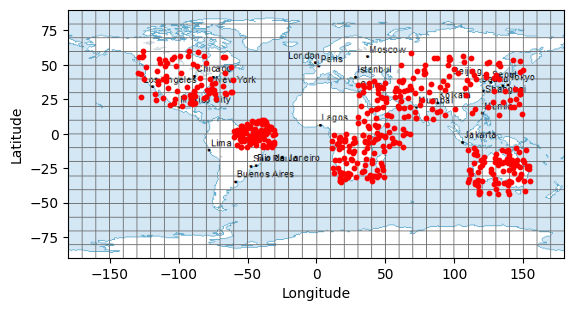

<Figure size 640x480 with 0 Axes>

In [186]:
import os

os.chdir(bug_repo_path)

%matplotlib inline

get_ipython().run_line_magic(
    "run",
    f'"{task6_program}"',
)

## Initial behaviour of the GPS plotting program

The selected version of `gps-plotter.py` was executed before debugging so
that its unexpected behaviour could be reproduced.

The program displayed GPS coordinates on a Plate Carrée world map. The
debugging investigation below examines the coordinate associated with the
unexpected point and determines why it is outside the valid geographic
bounds.

In [187]:
from pathlib import Path
import subprocess

if task6_mode == "historical-loop-counter":
    pdb_commands = [
        pdb_break_command,
        "c",
        "l",
        "p loop_counter",
        "pp locals()",
        "n",
        "pp locals()",
        "q",
    ]

else:
    pdb_commands = [
        pdb_break_command,
        "c",
        "l",
        "p lat",
        "p lon",
        "pp locals()",
        "n",
        "pp locals()",
        "q",
    ]

pdb_input = "\n".join(pdb_commands) + "\n"

pdb_result = subprocess.run(
    [
        "python",
        "-m",
        "pdb",
        task6_program,
    ],
    cwd=bug_repo_path,
    input=pdb_input,
    text=True,
    capture_output=True,
    timeout=120,
)

print("PDB return code:", pdb_result.returncode)

print("\nPDB standard output:")
print(pdb_result.stdout)

if pdb_result.stderr:
    print("\nPDB standard error:")
    print(pdb_result.stderr)

project_repo_path = Path("/content/Project-Repository")

pdb_log_path = (
    project_repo_path
    / "reports"
    / "pdb_session.txt"
)

pdb_log_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

pdb_log_path.write_text(
    "Commands entered:\n"
    + pdb_input
    + "\nPDB output:\n"
    + pdb_result.stdout
    + "\nPDB errors:\n"
    + pdb_result.stderr,
    encoding="utf-8",
)

print(f"\nPDB session saved to: {pdb_log_path}")

PDB return code: 0

PDB standard output:
> /content/MMA3001-Buggy-Code/gps-plotter.py(1)<module>()
-> import math
(Pdb) Breakpoint 1 at /content/MMA3001-Buggy-Code/gps-plotter.py:21
(Pdb) > /content/MMA3001-Buggy-Code/gps-plotter.py(21)load_gps_data()
-> if math.isnan(lat) or abs(lat) > 90 or abs(lon) > 180:
(Pdb)  16  	    coords = []
 17  	    with open(filename) as f:
 18  	        for line in f:
 19  	            lat, lon = line.strip().split(',')
 20  	            lat, lon = float(lat), float(lon)
 21 B->	            if math.isnan(lat) or abs(lat) > 90 or abs(lon) > 180:
 22  	                continue
 23  	            coords.append((lat, lon))
 24  	    return coords
 25  	
 26  	# --- Step 2: Plot on world map ---
(Pdb) 95.9871116971152
(Pdb) 10.303389172138218
(Pdb) {'coords': [(-9.58449181114532, 63.041732591094316),
            (30.348490880502702, 33.81972565867803),
            (-14.551852861128697, 114.50020031989965),
            (25.030556522453757, 145.1643003020335),
 

## Reproducing the interactive `pdb` session

The same investigation can be reproduced manually using the Colab Terminal.

Open **Terminal** and enter:

```bash
cd /content/MMA3001-Buggy-Code
python -m pdb gps-plotter.py

In [188]:
from pathlib import Path
import math

gps_data_path = bug_repo_path / "gps_points.txt"

if not gps_data_path.exists():
    possible_data_files = sorted(
        bug_repo_path.rglob("*gps*.txt")
    )

    if not possible_data_files:
        raise FileNotFoundError(
            "No GPS text-data file was found."
        )

    gps_data_path = possible_data_files[0]

invalid_rows = []

for line_number, raw_line in enumerate(
    gps_data_path.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines(),
    start=1,
):
    stripped_line = raw_line.strip()

    if not stripped_line:
        continue

    try:
        latitude_text, longitude_text = stripped_line.split(",")

        latitude = float(latitude_text)
        longitude = float(longitude_text)

    except (ValueError, TypeError):
        invalid_rows.append(
            (
                line_number,
                None,
                None,
                stripped_line,
                "Could not parse coordinate",
            )
        )
        continue

    invalid_reason = None

    if math.isnan(latitude) or math.isnan(longitude):
        invalid_reason = "NaN coordinate"

    elif abs(latitude) > 90:
        invalid_reason = "Latitude outside -90 to 90"

    elif abs(longitude) > 180:
        invalid_reason = "Longitude outside -180 to 180"

    if invalid_reason:
        invalid_rows.append(
            (
                line_number,
                latitude,
                longitude,
                stripped_line,
                invalid_reason,
            )
        )

print(f"GPS data file: {gps_data_path}")
print(f"Invalid rows found: {len(invalid_rows)}\n")

for row in invalid_rows:
    print(
        f"Line {row[0]}: "
        f"latitude={row[1]}, "
        f"longitude={row[2]}, "
        f"reason={row[4]}"
    )

GPS data file: /content/MMA3001-Buggy-Code/gps_points.txt
Invalid rows found: 2

Line 412: latitude=95.9871116971152, longitude=10.303389172138218, reason=Latitude outside -90 to 90
Line 480: latitude=nan, longitude=120.9992465405, reason=NaN coordinate


In [189]:
from pathlib import Path
import subprocess

diff_result = subprocess.run(
    [
        "git",
        "-C",
        str(bug_repo_path),
        "diff",
        f"{task6_commit}..main",
        "--",
        task6_program,
    ],
    text=True,
    capture_output=True,
)

source_diff = diff_result.stdout

if source_diff.strip():
    print("Difference between selected version and current main:\n")
    print(source_diff)

    source_diff_path = (
        project_repo_path
        / "docs"
        / "task6_source_diff.patch"
    )

    source_diff_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    source_diff_path.write_text(
        source_diff,
        encoding="utf-8",
    )

    print(f"\nDiff saved to: {source_diff_path}")

else:
    source_diff_path = None

    print(
        "No source difference was found for this file "
        "between the selected version and main."
    )

No source difference was found for this file between the selected version and main.


In [190]:
from pathlib import Path

project_repo_path = Path("/content/Project-Repository")
debugging_report_path = (
    project_repo_path
    / "docs"
    / "pdb_debugging_report.md"
)

debugging_report_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

# Evidence already obtained from the debugger and GPS-data scan.
observed_behaviour = (
    "The GPS data file contains invalid geographic coordinates. "
    "The current version of the program detects these records and "
    "prevents them from being plotted."
)

relevant_variable = "lat"

incorrect_value = (
    "95.9871116971152 at GPS data line 412, with longitude "
    "10.303389172138218"
)

expected_value = (
    "Latitude must remain between -90 and 90 degrees. "
    "Longitude must remain between -180 and 180 degrees."
)

bug_cause = (
    "The input file contains an invalid latitude greater than 90 degrees. "
    "It also contains a later record whose latitude is NaN."
)

bug_fix = (
    "Validate every parsed coordinate before appending it to the plotting "
    "list. Skip NaN values, latitude outside ±90 degrees, and longitude "
    "outside ±180 degrees."
)

excerpt_start = max(1, breakpoint_line - 8)
excerpt_end = min(
    len(source_lines),
    breakpoint_line + 8,
)

source_excerpt = "\n".join(
    f"{line_number:4}: {source_lines[line_number - 1]}"
    for line_number in range(
        excerpt_start,
        excerpt_end + 1,
    )
)

report_lines = [
    "# PDB Debugging Report",
    "",
    "## Program investigated",
    "",
    f"`{task6_program}` from the supplied "
    "`MMA3001-Buggy-Code` repository.",
    "",
    "## Repository version",
    "",
    f"- Commit: `{task6_commit}`",
    f"- Debugging mode: `{task6_mode}`",
    "",
    "## Initial behaviour",
    "",
    observed_behaviour,
    "",
    "## Debugging method",
    "",
    "The program was started using:",
    "",
    "```text",
    f"python -m pdb {task6_program}",
    "```",
    "",
    "The conditional breakpoint was:",
    "",
    "```text",
    pdb_break_command,
    "```",
    "",
    "Execution was continued using `c`. The commands `l`, `p lat`, "
    "`p lon`, `pp locals()`, and `n` were used to inspect the program.",
    "",
    "The complete debugger output is stored in:",
    "",
    "```text",
    "reports/pdb_session.txt",
    "```",
    "",
    "## Debugger findings",
    "",
    f"- Relevant variable: `{relevant_variable}`",
    f"- Incorrect value: {incorrect_value}",
    f"- Expected value or range: {expected_value}",
    "",
    "The GPS-data scan also found:",
    "",
    "- Line 412: latitude `95.9871116971152`",
    "- Line 480: latitude `NaN`",
    "",
    "## Cause of the issue",
    "",
    bug_cause,
    "",
    "## Required correction",
    "",
    bug_fix,
    "",
    "## Relevant source-code context",
    "",
    "```python",
    source_excerpt,
    "```",
    "",
    "## Conclusion",
    "",
    "The conditional breakpoint stopped execution when the invalid "
    "coordinate was being processed. This exposed the incorrect latitude "
    "without requiring manual stepping through every earlier record. "
    "The current source includes validation that skips the invalid data "
    "before plotting.",
    "",
]

report = "\n".join(report_lines)

debugging_report_path.write_text(
    report,
    encoding="utf-8",
)

print(f"Report created: {debugging_report_path}")
print("\n" + report)

Report created: /content/Project-Repository/docs/pdb_debugging_report.md

# PDB Debugging Report

## Program investigated

`gps-plotter.py` from the supplied `MMA3001-Buggy-Code` repository.

## Repository version

- Commit: `9294a6c54b695807585fb26b0cea725d6d04b26a`
- Debugging mode: `current-coordinate-validation`

## Initial behaviour

The GPS data file contains invalid geographic coordinates. The current version of the program detects these records and prevents them from being plotted.

## Debugging method

The program was started using:

```text
python -m pdb gps-plotter.py
```

The conditional breakpoint was:

```text
b 21, math.isnan(lat) or abs(lat) > 90 or abs(lon) > 180
```

Execution was continued using `c`. The commands `l`, `p lat`, `p lon`, `pp locals()`, and `n` were used to inspect the program.

The complete debugger output is stored in:

```text
reports/pdb_session.txt
```

## Debugger findings

- Relevant variable: `lat`
- Incorrect value: 95.9871116971152 at GPS data

In [191]:
from pathlib import Path

required_task6_files = [
    Path(
        "/content/Project-Repository/"
        "docs/pdb_debugging_report.md"
    ),
    Path(
        "/content/Project-Repository/"
        "reports/pdb_session.txt"
    ),
]

for file_path in required_task6_files:
    if not file_path.exists():
        raise FileNotFoundError(
            f"Required Task 6 file is missing: {file_path}"
        )

    print(f"Found: {file_path}")
    print(f"Size: {file_path.stat().st_size:,} bytes\n")

Found: /content/Project-Repository/docs/pdb_debugging_report.md
Size: 2,648 bytes

Found: /content/Project-Repository/reports/pdb_session.txt
Size: 45,439 bytes



In [192]:
from pathlib import Path
from IPython.display import Markdown, display

report_path = Path(
    "/content/Project-Repository/"
    "docs/pdb_debugging_report.md"
)

display(
    Markdown(
        report_path.read_text(
            encoding="utf-8"
        )
    )
)

# PDB Debugging Report

## Program investigated

`gps-plotter.py` from the supplied `MMA3001-Buggy-Code` repository.

## Repository version

- Commit: `9294a6c54b695807585fb26b0cea725d6d04b26a`
- Debugging mode: `current-coordinate-validation`

## Initial behaviour

The GPS data file contains invalid geographic coordinates. The current version of the program detects these records and prevents them from being plotted.

## Debugging method

The program was started using:

```text
python -m pdb gps-plotter.py
```

The conditional breakpoint was:

```text
b 21, math.isnan(lat) or abs(lat) > 90 or abs(lon) > 180
```

Execution was continued using `c`. The commands `l`, `p lat`, `p lon`, `pp locals()`, and `n` were used to inspect the program.

The complete debugger output is stored in:

```text
reports/pdb_session.txt
```

## Debugger findings

- Relevant variable: `lat`
- Incorrect value: 95.9871116971152 at GPS data line 412, with longitude 10.303389172138218
- Expected value or range: Latitude must remain between -90 and 90 degrees. Longitude must remain between -180 and 180 degrees.

The GPS-data scan also found:

- Line 412: latitude `95.9871116971152`
- Line 480: latitude `NaN`

## Cause of the issue

The input file contains an invalid latitude greater than 90 degrees. It also contains a later record whose latitude is NaN.

## Required correction

Validate every parsed coordinate before appending it to the plotting list. Skip NaN values, latitude outside ±90 degrees, and longitude outside ±180 degrees.

## Relevant source-code context

```python
  13:         list[tuple[float, float]]: A list of (latitude, longitude) tuples for valid GPS points.
  14:             Invalid points (NaN latitude, latitude > 90, or longitude > 180) are skipped.
  15:     """
  16:     coords = []
  17:     with open(filename) as f:
  18:         for line in f:
  19:             lat, lon = line.strip().split(',')
  20:             lat, lon = float(lat), float(lon)
  21:             if math.isnan(lat) or abs(lat) > 90 or abs(lon) > 180:
  22:                 continue
  23:             coords.append((lat, lon))
  24:     return coords
  25: 
  26: # --- Step 2: Plot on world map ---
  27: def plot_gps_points(coords, map_image="Plate-Carree-Projection.png"):
  28:     """Plots a list of GPS coordinates on a world map image.
  29: 
```

## Conclusion

The conditional breakpoint stopped execution when the invalid coordinate was being processed. This exposed the incorrect latitude without requiring manual stepping through every earlier record. The current source includes validation that skips the invalid data before plotting.


In [193]:
import subprocess
from pathlib import Path

bug_repo_path = Path(
    "/content/MMA3001-Buggy-Code"
)

subprocess.run(
    [
        "git",
        "-C",
        str(bug_repo_path),
        "switch",
        "main",
    ],
    check=True,
)

print("Teaching repository restored to main.")

subprocess.run(
    [
        "git",
        "-C",
        str(bug_repo_path),
        "status",
        "--short",
        "--branch",
    ],
    check=True,
)

Teaching repository restored to main.


CompletedProcess(args=['git', '-C', '/content/MMA3001-Buggy-Code', 'status', '--short', '--branch'], returncode=0)

In [194]:
import subprocess
from pathlib import Path

project_repo_path = Path(
    "/content/Project-Repository"
)

files_to_stage = [
    "docs/pdb_debugging_report.md",
    "reports/pdb_session.txt",
]

subprocess.run(
    [
        "git",
        "-C",
        str(project_repo_path),
        "add",
        *files_to_stage,
    ],
    check=True,
)

print("Task 6 files staged.")

subprocess.run(
    [
        "git",
        "-C",
        str(project_repo_path),
        "status",
        "--short",
    ],
    check=True,
)

Task 6 files staged.


CompletedProcess(args=['git', '-C', '/content/Project-Repository', 'status', '--short'], returncode=0)

In [195]:
import subprocess
from pathlib import Path

project_repo_path = Path(
    "/content/Project-Repository"
)

staged_changes = subprocess.run(
    [
        "git",
        "-C",
        str(project_repo_path),
        "diff",
        "--cached",
        "--quiet",
    ]
)

if staged_changes.returncode == 0:
    print("No new Task 6 changes need to be committed.")

else:
    subprocess.run(
        [
            "git",
            "-C",
            str(project_repo_path),
            "commit",
            "-m",
            "Add pdb debugging investigation",
        ],
        check=True,
    )

    subprocess.run(
        [
            "git",
            "-C",
            str(project_repo_path),
            "push",
            "origin",
            "main",
        ],
        check=True,
    )

    print("Task 6 committed and pushed successfully.")

No new Task 6 changes need to be committed.


In [196]:
%cd /content/Project-Repository

print("Task 6 evidence:")
!ls -lh docs/pdb_debugging_report.md
!ls -lh reports/pdb_session.txt

print("\nGit status:")
!git status

print("\nRecent commits:")
!git log --oneline -8

/content/Project-Repository
Task 6 evidence:
-rw-r--r-- 1 root root 2.6K Jul 29 08:27 docs/pdb_debugging_report.md
-rw-r--r-- 1 root root 45K Jul 29 08:27 reports/pdb_session.txt

Git status:
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean

Recent commits:
de9d7ee (HEAD -> main, origin/main, origin/HEAD) Add matrix tests and pytest HTML report
3939b1f Add AI usage statement to README
d9225a2 Set up initial project structure
d6443fb Add matrix tests and pytest HTML report
e607b36 Add AI usage statement to README
da55ad9 Set up initial project structure
de800d8 Add pdb debugging investigation
f980382 Add matrix tests and pytest HTML report


In [197]:
import subprocess
from pathlib import Path

project_repo_path = Path("/content/Project-Repository")

staged_changes = subprocess.run(
    [
        "git",
        "-C",
        str(project_repo_path),
        "diff",
        "--cached",
        "--quiet",
    ]
)

if staged_changes.returncode == 0:
    print("No new Task 6 changes need to be committed.")
else:
    subprocess.run(
        [
            "git",
            "-C",
            str(project_repo_path),
            "commit",
            "-m",
            "Add pdb debugging investigation",
        ],
        check=True,
    )

    subprocess.run(
        [
            "git",
            "-C",
            str(project_repo_path),
            "push",
            "origin",
            "main",
        ],
        check=True,
    )

    print("Task 6 committed and pushed successfully.")

No new Task 6 changes need to be committed.


In [198]:
%cd /content/Project-Repository

print("Required files:")
!ls -lh docs/pdb_debugging_report.md
!ls -lh reports/pdb_session.txt
!ls -lh reports/pytest_report.html
!ls -lh notebooks/Project-Week1.ipynb

print("\nGit status:")
!git status

print("\nRecent commits:")
!git log --oneline -8

/content/Project-Repository
Required files:
-rw-r--r-- 1 root root 2.6K Jul 29 08:27 docs/pdb_debugging_report.md
-rw-r--r-- 1 root root 45K Jul 29 08:27 reports/pdb_session.txt
-rw-r--r-- 1 root root 36K Jul 29 08:26 reports/pytest_report.html
-rw-r--r-- 1 root root 8.8K Jul 29 08:02 notebooks/Project-Week1.ipynb

Git status:
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean

Recent commits:
de9d7ee (HEAD -> main, origin/main, origin/HEAD) Add matrix tests and pytest HTML report
3939b1f Add AI usage statement to README
d9225a2 Set up initial project structure
d6443fb Add matrix tests and pytest HTML report
e607b36 Add AI usage statement to README
da55ad9 Set up initial project structure
de800d8 Add pdb debugging investigation
f980382 Add matrix tests and pytest HTML report
